# Bonus 3 — Robust CIRCLE fitting with RANSAC

*Based on the RANSAC line-fitting notebook by Tarlan Ahadli (projects by Prof. Hajder Levente), modified for the bonus assignment.*

**What is new in this notebook:** the full pipeline of the original notebook, but the model is a **circle**
instead of a line. The structure stays exactly the same; only the model-specific pieces change:

| Part | Line (original) | Circle (this notebook) |
|---|---|---|
| Parameters | $(a, b, c)$ | centre $(c_x, c_y)$ and radius $r$ |
| Minimal sample | 2 points | **3 points** |
| Model from minimal sample | line through 2 points | circle through 3 points |
| Distance of a point | $\lvert ax + by + c \rvert$ | $\big\lvert \sqrt{(x-c_x)^2 + (y-c_y)^2} - r \big\rvert$ |
| Over-determined refinement | least squares on all inliers | least squares on all inliers |

## Step 1 — **CHANGED:** synthetic circle data

* **Inliers:** pick a random angle $\theta \sim \text{Uniform}(0, 2\pi)$ and put the point on the circle,
  then add the same Gaussian noise as before ($\sigma = 10$ px):
  $$
  x = c_x + r\cos\theta + \mathcal{N}(0, 10), \qquad y = c_y + r\sin\theta + \mathcal{N}(0, 10)
  $$
* **Outliers:** uniformly random in the 640 × 480 image *(same as the original)*.

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

def init_random(seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

def generate_circle_data(N, center, radius, inlier_ratio=0.5):
    WIDTH, HEIGHT = 640, 480
    N_inlier = int(N * inlier_ratio)
    N_outlier = N - N_inlier

    points = []

    for _ in range(N_inlier):
        theta = random.random() * 2.0 * np.pi
        x = center[0] + radius * np.cos(theta) + np.random.normal(0.0, 10.0)
        y = center[1] + radius * np.sin(theta) + np.random.normal(0.0, 10.0)
        points.append((x, y))

    for _ in range(N_outlier):
        points.append((random.random() * WIDTH, random.random() * HEIGHT))

    return np.array(points, dtype=float)

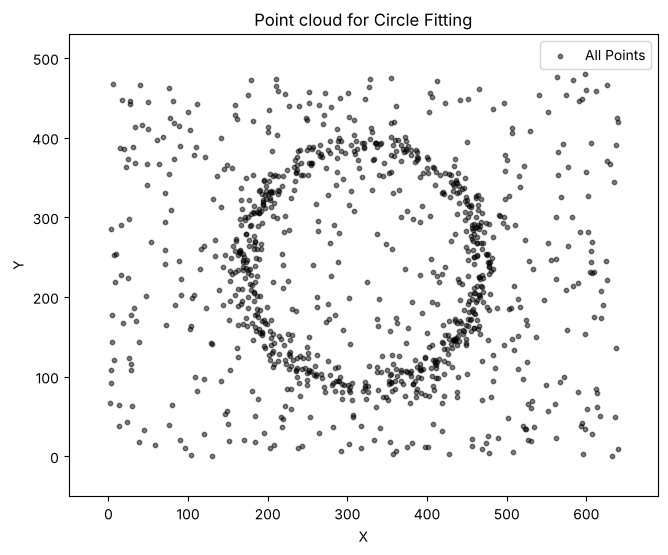

In [2]:
init_random(seed=0)

N = 1000
true_center = (320.0, 240.0)
true_radius = 150.0
points = generate_circle_data(N, true_center, true_radius, inlier_ratio=0.5)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(points[:, 0], points[:, 1], s=10, c='k', alpha=0.5, label='All Points')
ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_aspect('equal')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Point cloud for Circle Fitting')
ax.legend()
plt.show()

## Step 2 — **NEW:** circle helpers

### Fitting a circle: one trick for both 3 points and many points

The circle equation $(x - c_x)^2 + (y - c_y)^2 = r^2$ is not linear in $c_x, c_y, r$. But if we expand it:

$$
x^2 + y^2 \underbrace{- 2c_x}_{D}\, x \underbrace{- 2c_y}_{E}\, y + \underbrace{c_x^2 + c_y^2 - r^2}_{F} = 0
$$

we get an equation that is **linear in the new unknowns $D, E, F$**:

$$
D\,x_i + E\,y_i + F = -(x_i^2 + y_i^2)
$$

Each point gives one such equation. Stacking them:

$$
\underbrace{\begin{bmatrix} x_1 & y_1 & 1 \\ x_2 & y_2 & 1 \\ \vdots & \vdots & \vdots \end{bmatrix}}_{A}
\begin{bmatrix} D \\ E \\ F \end{bmatrix}
=
\begin{bmatrix} -(x_1^2 + y_1^2) \\ -(x_2^2 + y_2^2) \\ \vdots \end{bmatrix}
$$

* With **3 points** this is a 3 × 3 system → the exact circle through the 3 points (used inside RANSAC).
* With **many points** it is over-determined → the least-squares circle (used for the final refinement).

So `np.linalg.lstsq` handles both cases with the same function. At the end we convert back:

$$
c_x = -\frac{D}{2}, \qquad c_y = -\frac{E}{2}, \qquad r = \sqrt{c_x^2 + c_y^2 - F}
$$

If the 3 points are **collinear** there is no circle through them: the matrix $A$ then has rank < 3,
and the function returns `None` (same idea as the "points too close" check for lines).

### Distance of a point to the circle
The distance from the centre minus the radius:

$$
d = \big\lvert \sqrt{(x - c_x)^2 + (y - c_y)^2} - r \big\rvert
$$

In [3]:
def fit_circle(pts):
    x, y = pts[:, 0], pts[:, 1]
    A = np.column_stack([x, y, np.ones(len(x))])    # one row per point: [x_i, y_i, 1]
    rhs = -(x**2 + y**2)
    solution, _, rank, _ = np.linalg.lstsq(A, rhs, rcond=None)
    if rank < 3:                                     # e.g. 3 collinear points -> no circle
        return None
    D, E, F = solution
    cx, cy = -D / 2, -E / 2
    r = math.sqrt(cx**2 + cy**2 - F)
    return cx, cy, r

def distance_point_circle(circle_params, point):
    cx, cy, r = circle_params
    x, y = point
    return abs(math.sqrt((x - cx)**2 + (y - cy)**2) - r)

A quick sanity check: $(7, 3)$, $(2, 8)$ and $(-3, 3)$ all lie on the circle with centre $(2, 3)$ and radius $5$.

In [4]:
cx, cy, r = fit_circle(np.array([[7.0, 3.0], [2.0, 8.0], [-3.0, 3.0]]))
print(f"centre=({cx:.2f}, {cy:.2f}), r={r:.2f}")                    # expected centre=(2, 3), r=5
print(fit_circle(np.array([[0.0, 0.0], [1.0, 1.0], [2.0, 2.0]])))   # collinear -> None

centre=(2.00, 3.00), r=5.00
None


`iteration_number` is copied unchanged. The only difference is that we call it with `sample_size = 3`.
With 3 points per sample, an all-inlier sample is less likely ($w^3$ instead of $w^2$), so RANSAC needs more iterations.

In [5]:
def iteration_number(confidence, sample_size, inliers, N):
    if inliers == 0:
        return float('inf')
    ratio = inliers / float(N)
    top = math.log(1.0 - confidence)
    bottom = math.log(1.0 - ratio**sample_size)
    return math.ceil(top / bottom) if bottom != 0 else float('inf')

## Step 3 — **CHANGED:** RANSAC for circles

> **Small fix compared to the original:** the original loop was `for _ in range(max_iterations)`.
> `range(...)` is created only once, so lowering `max_iterations` inside the loop had no effect
> and RANSAC always ran all 2000 iterations. A `while` loop re-checks the limit every time,
> so the adaptive stopping rule from `iteration_number` really works now.


Compared to the line version only these things change:
* sample **3** points instead of 2,
* `fit_circle` / `distance_point_circle` instead of the line functions,
* `iteration_number(..., 3, ...)` instead of `2`.

In [6]:
def ransac_circle(points, max_iterations=2000, sigma=10.0, confidence=0.95):
    best_inliers_count = 0
    best_circle, best_inliers_list = None, []

    i = 0
    while i < max_iterations:
        i += 1
        idx = np.random.choice(len(points), 3, replace=False)
        circle_params = fit_circle(points[idx])
        if circle_params is None:
            continue

        inliers = [pt for pt in points if distance_point_circle(circle_params, pt) < sigma]

        if len(inliers) > best_inliers_count:
            best_inliers_count, best_circle, best_inliers_list = len(inliers), circle_params, inliers
            max_iterations = min(max_iterations, iteration_number(confidence, 3, best_inliers_count, len(points)))

    print(f"RANSAC stopped after {i} iterations")
    return best_circle, np.array(best_inliers_list)

## Step 4 — Run RANSAC, then the over-determined refinement

The refinement is just `fit_circle` called with **all inliers** instead of 3 points.

> **Note:** this least-squares fit minimises the *algebraic* error of the expanded equation, not the exact
> geometric distance. For points spread around the whole circle, like here, the two give practically the same result,
> and the algebraic version needs no iterations, so it is the simplest choice.

In [7]:
ransac_circle_params, inliers = ransac_circle(points)
refined_circle = fit_circle(inliers)

def rms_distance(circle_params, pts):
    return np.sqrt(np.mean([distance_point_circle(circle_params, pt)**2 for pt in pts]))

print(f"Number of inliers: {len(inliers)} out of {len(points)}")
print(f"True circle:                  centre=({true_center[0]:.1f}, {true_center[1]:.1f}), r={true_radius:.1f}")
print("RANSAC circle  (3 points):    centre=({:.1f}, {:.1f}), r={:.1f}".format(*ransac_circle_params))
print("Refined circle (all inliers): centre=({:.1f}, {:.1f}), r={:.1f}".format(*refined_circle))
print()
print(f"RMS inlier distance - RANSAC:  {rms_distance(ransac_circle_params, inliers):.2f} px")
print(f"RMS inlier distance - refined: {rms_distance(refined_circle, inliers):.2f} px")

RANSAC stopped after 68 iterations
Number of inliers: 352 out of 1000
True circle:                  centre=(320.0, 240.0), r=150.0
RANSAC circle  (3 points):    centre=(316.2, 239.4), r=153.9
Refined circle (all inliers): centre=(317.0, 240.2), r=153.5

RMS inlier distance - RANSAC:  5.36 px
RMS inlier distance - refined: 5.30 px


## Step 5 — Results

`plt.Circle` draws a circle from its centre and radius. `set_aspect('equal')` is important, otherwise circles look like ellipses.

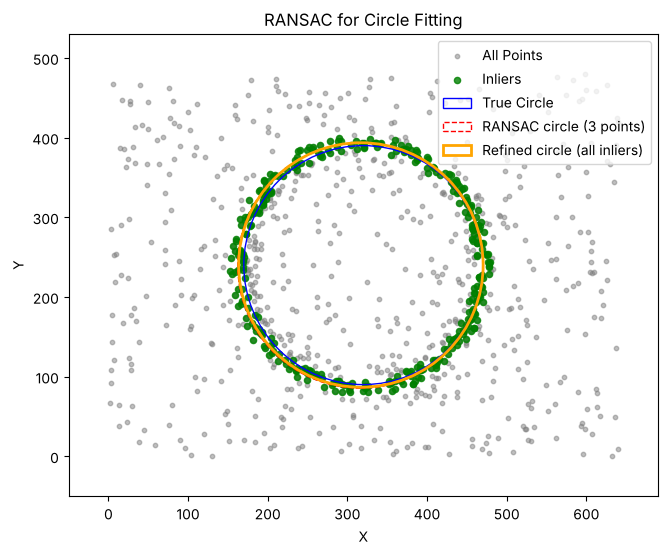

In [8]:
def draw_circle(ax, circle_params, **kwargs):
    cx, cy, r = circle_params
    ax.add_patch(plt.Circle((cx, cy), r, fill=False, **kwargs))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(points[:, 0], points[:, 1], s=10, c='gray', alpha=0.5, label='All Points')
ax.scatter(inliers[:, 0], inliers[:, 1], s=20, c='green', alpha=0.8, label='Inliers')

draw_circle(ax, (true_center[0], true_center[1], true_radius), color='blue', label='True Circle')
draw_circle(ax, ransac_circle_params, color='red', ls='--', label='RANSAC circle (3 points)')
draw_circle(ax, refined_circle, color='orange', lw=2, label='Refined circle (all inliers)')

ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_aspect('equal')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('RANSAC for Circle Fitting')
ax.legend(loc='upper right')
plt.show()

## Conclusion

* The RANSAC pipeline is **model-independent**: to go from lines to circles we only replaced the minimal-sample fit,
  the distance function and the sample size (2 → 3).
* Writing the circle as $x^2 + y^2 + Dx + Ey + F = 0$ makes the problem **linear**, so the same small function gives
  the exact circle through 3 points (inside RANSAC) and the least-squares circle through all inliers (final refinement).
* Even with 50 % outliers, RANSAC finds the circle, and the over-determined refinement brings it closer to the inliers.